# 311 Service Request Equity Analysis — San Antonio

Examines whether 311 service request resolution times vary by council district and correlate with neighborhood income. Uses City of San Antonio open 311 data joined to Census ACS 2020 block group demographics via a TIGER spatial intersection weighted by block group area.

## 1. Imports

In [5]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import time

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import contextily as cx
from matplotlib.ticker import StrMethodFormatter

import geopandas as gpd
import censusdata
from dotenv import load_dotenv

## 2. Data Acquisition

311 data is pulled from the City of San Antonio ArcGIS REST API (2022 onward) and cached locally. Re-run the API cell only when refreshing the dataset; otherwise load from CSV.

### 2a. API Pull (run once to refresh)

In [6]:
# REST API
ENDPOINT = (
    "https://services.arcgis.com/g1fRTDLeMgspWrYp/arcgis/rest/services"
    "/311_All_Service_Calls/FeatureServer/0/query"
)

base_params = {
        "where":            "OPENEDDATETIME >= DATE '2022-01-01'",
        "outFields":        (
            "*"
        ),
        "f":                "json",
        "resultRecordCount": 2000,
    }

max_records = 500000

records = []
offset = 0
page_size = 2000

print("Fetching 311 data...")
while len(records) < max_records:
    params = {**base_params, "resultOffset": offset}
    resp = requests.get(ENDPOINT, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    if "error" in data:
        print("API error:", data)
        break

    features = data.get("features", [])
    if not features:
        break

    records.extend([f["attributes"] for f in features])
    print(f"Fetched {len(records)} records so far...")

    # ArcGIS signals no more pages by returning fewer than page_size row

    if len(features) < page_size:
        break

    offset += page_size
    time.sleep(0.25)

df = pd.DataFrame(records)
print(f"Done - {len(df):,} total records pulled")

Fetching 311 data...
Fetched 2000 records so far...
Fetched 4000 records so far...
Fetched 6000 records so far...
Fetched 8000 records so far...
Fetched 10000 records so far...
Fetched 12000 records so far...
Fetched 14000 records so far...
Fetched 16000 records so far...
Fetched 18000 records so far...
Fetched 20000 records so far...
Fetched 22000 records so far...
Fetched 24000 records so far...
Fetched 26000 records so far...
Fetched 28000 records so far...
Fetched 30000 records so far...
Fetched 32000 records so far...
Fetched 34000 records so far...
Fetched 36000 records so far...
Fetched 38000 records so far...
Fetched 40000 records so far...
Fetched 42000 records so far...
Fetched 44000 records so far...
Fetched 46000 records so far...
Fetched 48000 records so far...
Fetched 50000 records so far...
Fetched 52000 records so far...
Fetched 54000 records so far...
Fetched 56000 records so far...
Fetched 58000 records so far...
Fetched 60000 records so far...
Fetched 62000 records s

### 2b. Load from CSV

In [7]:
df = pd.read_csv('311_data.csv', parse_dates=['OpenedDateTime', 'ClosedDateTime', 'SLADate', 'ReportStartingDate', 'ReportEndingDate'])

# Fix datetime columns (stored as ms epoch in raw CSV)
for col in ['OpenedDateTime', 'ClosedDateTime', 'SLADate', 'ReportStartingDate', 'ReportEndingDate']:
    df[col] = pd.to_datetime(pd.to_numeric(df[col], errors='coerce'), unit='ms', errors='coerce')

# Resave with parsed datetypes
df.to_csv("311_Data.csv", index=False)

## 3. Exploratory Data Analysis

In [8]:
df.columns.tolist()

['OBJECTID',
 'Category',
 'CaseID',
 'OpenedDateTime',
 'SLADate',
 'ClosedDateTime',
 'LateYesNo',
 'Department',
 'ReasonName',
 'TypeName',
 'CaseStatus',
 'SourceID',
 'ObjectDescription',
 'CouncilDistrict',
 'XCOORD',
 'YCOORD',
 'ReportStartingDate',
 'ReportEndingDate']

In [9]:
df.dtypes

OBJECTID                       int64
Category                         str
CaseID                         int64
OpenedDateTime        datetime64[ms]
SLADate               datetime64[ms]
ClosedDateTime        datetime64[ms]
LateYesNo                        str
Department                       str
ReasonName                       str
TypeName                         str
CaseStatus                       str
SourceID                         str
ObjectDescription                str
CouncilDistrict                int64
XCOORD                       float64
YCOORD                       float64
ReportStartingDate    datetime64[ms]
ReportEndingDate      datetime64[ms]
dtype: object

In [10]:
df.head()

,OBJECTID,Category,CaseID,OpenedDateTime,SLADate,ClosedDateTime,LateYesNo,Department,ReasonName,TypeName,CaseStatus,SourceID,ObjectDescription,CouncilDistrict,XCOORD,YCOORD,ReportStartingDate,ReportEndingDate
0,4227,Animals,1017286476,53971-01-26,53979-04-14,NaT,YES,Animal Care Services,Field Operations,Cruelty Neglect(Animal Neglect),Open,311 Mobile App,"305 PAUL ST, SAN ANTONIO, 78203",2,2138360.0,13698983.0,57073-02-12,58072-06-14
1,4228,Information,1017287897,53976-07-18,53995-09-17,NaT,YES,311,Customer Service,Customer Service(Complaint),Open,Constituent Call,"1 HAVEN FOR HOPE WAY, SAN ANTONIO, 78207",5,2125765.0,13705268.0,57073-02-12,58072-06-14
2,4229,Animals,1017288663,53976-07-18,53979-04-14,NaT,YES,Animal Care Services,Field Operations,Trapped/Confined,Open,Constituent Call,"218 BURKE AVE, SAN ANTONIO, 78225",5,2116011.0,13686778.0,57073-02-12,58072-06-14
3,4230,Information,1017289174,53976-07-18,53995-09-17,NaT,YES,311,Customer Service,Customer Service(Complaint),Open,Constituent Call,"7718 ABBEY PLACE, SAN ANTONIO, 78218",2,2168626.0,13731557.0,57073-02-12,58072-06-14
4,4231,Animals,1017289486,53976-07-18,54003-12-04,NaT,YES,Animal Care Services,Field Operations,Animal Bite(Non-Critical),Open,Constituent Call,"Brackenridge Park, 3700 N ST MARYS ST, SAN AN...",2,2135382.0,13714737.0,57073-02-12,58072-06-14


## 4. Feature Engineering & Cleaning

Filter to closed cases, compute resolution time in days, inspect negative values (data quality issue), and drop invalid records.

In [11]:
# Create features and filter
df_filtered = df[df['CaseStatus'] == 'Closed']

df_filtered['ResolutionTime'] = (df_filtered['ClosedDateTime'] - df_filtered['OpenedDateTime']).dt.days

# Check distribution — inspect negatives
print(df_filtered['ResolutionTime'].describe())

# Investigate negative resolution times
df_filtered[df_filtered['ResolutionTime'] == -21]

# Remove negatives and zeros
df_clean = df_filtered[(df_filtered['ResolutionTime'] > 0) ]

df_clean.head()
df_clean.dtypes

count    4.268690e+05
mean     1.519412e+04
std      5.190468e+04
min     -2.100000e+04
25%      1.000000e+03
50%      2.000000e+03
75%      7.000000e+03
max      1.327000e+06
Name: ResolutionTime, dtype: float64


OBJECTID                       int64
Category                         str
CaseID                         int64
OpenedDateTime        datetime64[ms]
SLADate               datetime64[ms]
ClosedDateTime        datetime64[ms]
LateYesNo                        str
Department                       str
ReasonName                       str
TypeName                         str
CaseStatus                       str
SourceID                         str
ObjectDescription                str
CouncilDistrict                int64
XCOORD                       float64
YCOORD                       float64
ReportStartingDate    datetime64[ms]
ReportEndingDate      datetime64[ms]
ResolutionTime               float64
dtype: object

## 5. Analysis

### 5a. SLA Performance

In [12]:
# Percentage late
late = df_clean[df_clean['LateYesNo'] == 'YES']
print(late['LateYesNo'].count() / len(df_clean))

0.17632885536718598


### 5b. Date Range

In [13]:
# What time frame are we working with
print(f" Starting date: {df_clean['OpenedDateTime'].min()} End date: {df_clean['OpenedDateTime'].max()}")

 Starting date: 54064-02-27 00:00:00 End date: 57894-06-28 00:00:00


### 5c. Resolution Time by Request Type and District

In [14]:
# Average resolution time by request type
avg_type = df_clean.groupby('TypeName')['ResolutionTime'].mean().reset_index()

avg_type.sort_values(ascending=False, by='ResolutionTime').head(10)

,TypeName,ResolutionTime
122,Pavement Marking Changes,447000.000000
59,Homeless Outreach,341120.000000
29,Dangerous Premise BSB Processed,316126.984127
202,Traffic Signals (New Signal),271393.638171
123,Pavement Markings (Bike Lanes),193947.368421
90,Parks Internal (Fit/Exer Equip_Missing Equipment),186166.666667
100,Parks Internal (Playground Fitness Equipment),125892.307692
103,Parks Internal (Playground_Missing Equipment),121820.000000
193,Sportsfield Court Maintenance(Painting),114000.000000
22,Certificate of Occupancy Investigation,108816.438356


In [15]:
# Resolution time by council district
avg_council = df_clean.groupby('CouncilDistrict')['ResolutionTime'].mean().reset_index()

avg_council.sort_values(ascending=False, by='ResolutionTime').head(10)

,CouncilDistrict,ResolutionTime
2,2,25689.348758
5,5,24130.281610
0,0,23264.686469
3,3,22954.423022
1,1,20350.373747
4,4,18374.850800
6,6,17016.860440
7,7,16671.863565
10,10,16549.243972
9,9,14893.888045


In [16]:
# Volume by category and district — are some districts filing more infrastructure complaints (potholes, lights) vs. others?
council_volume = df_clean['CouncilDistrict'].value_counts().reset_index()

council_volume.head(10)

,CouncilDistrict,count
0,5,43997
1,1,43211
2,3,42324
3,2,41751
4,4,33512
5,7,31429
6,10,26917
7,6,23309
8,9,17114
9,8,16570


### 5d. Category Mix — Districts 5 vs 10

In [17]:
# share of requests by category for each district
mix = df_clean[df_clean['CouncilDistrict'].isin([5, 10])].groupby(['CouncilDistrict', 'Category']).size()
mix = mix.groupby(level=0, group_keys=False).apply(lambda x: x / x.sum()).unstack(0)
print(mix)

CouncilDistrict                  5         10
Category                                     
Animals                    0.138782  0.068024
Dockless Vehicle           0.000364  0.000111
Graffiti                   0.000864  0.000372
Health & Sanitation        0.011092  0.013560
Information                0.004750  0.004941
No Category                0.001568  0.001858
Parks                      0.046776  0.024706
Property Maintenance       0.289747  0.312702
Solid Waste Services       0.415574  0.450236
Streets & Infrastructure   0.058390  0.084593
Traffic Signals and Signs  0.032093  0.038897


### 5e. Homeless & Sanitation Requests — Districts 2 vs 5

In [18]:
# Find relevant TypeName values
df[df['Category'].str.contains('Health|Homeless|Sanitation', case=False, na=False)]['TypeName'].value_counts()

homeless_sanitation = [
    'Homeless Encampment', 'Homeless Outreach',
    'Encampment Abatement', 'General Sanitation (Sanitary Conditions)'
]

counts = df_clean[df_clean['TypeName'].isin(homeless_sanitation)]\
    .groupby(['TypeName', 'CouncilDistrict'])\
    .size().unstack(fill_value=0)

medians = df_clean[df_clean['TypeName'].isin(homeless_sanitation)]\
    .groupby(['TypeName', 'CouncilDistrict'])['ResolutionTime']\
    .median().unstack()

print("=== Request Count ===")
print(counts[[5, 10]])
print("\n=== Median Resolution Days ===")
print(medians[[5, 10]])

print("=== Request Count ===")
print(counts[[5, 2]])
print("\n=== Median Resolution Days ===")
print(medians[[5, 2]])

=== Request Count ===
CouncilDistrict                            5    10
TypeName                                          
Encampment Abatement                        2    5
General Sanitation (Sanitary Conditions)   63   40
Homeless Encampment                       250  130
Homeless Outreach                           1    0

=== Median Resolution Days ===
CouncilDistrict                                 5        10
TypeName                                                   
Encampment Abatement                       14000.0  21000.0
General Sanitation (Sanitary Conditions)    2000.0   3000.0
Homeless Encampment                        42000.0  46500.0
Homeless Outreach                         147000.0      NaN
=== Request Count ===
CouncilDistrict                             5    2
TypeName                                          
Encampment Abatement                        2    5
General Sanitation (Sanitary Conditions)   63   60
Homeless Encampment                       250  220
Hom

## 6. Census & Spatial Data

Downloads ACS 2020 block group data for Bexar County, joins to TIGER geometries using a 12-digit GEOID, and intersects with council district boundaries to produce area-weighted income estimates by district.

### 6a. ACS Download

In [20]:
# Load Census API key from environment
load_dotenv()
CENSUS_KEY = os.getenv('CENSUS_API_KEY')

bexarbg = censusdata.download(
    'acs5', 2020,
    censusdata.censusgeo([('state', '48'), ('county', '029'), ('block group', '*')]),
    ['B01003_001E', 'B19013_001E', 'B01002_001E'],
    key=CENSUS_KEY
)

bexarbg = bexarbg.rename(columns={
    'B01003_001E': 'total_population',
    'B19013_001E': 'median_hh_income',
    'B01002_001E': 'median_age'
})

In [21]:
bexarbg.head()

,total_population,median_hh_income,median_age
"Block Group 3, Census Tract 1103, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:110300> block group:3",777,65121,37.5
"Block Group 2, Census Tract 1106, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:110600> block group:2",1556,16161,51.0
"Block Group 1, Census Tract 1110, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111000> block group:1",833,21071,33.4
"Block Group 3, Census Tract 1110, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111000> block group:3",1046,60735,28.8
"Block Group 3, Census Tract 1111, Bexar County, Texas: Summary level: 150, state:48> county:029> tract:111100> block group:3",643,42031,32.7


### 6b. TIGER Block Group Shapefiles

In [22]:
tiger = gpd.read_file(r"tl_2023_48_bg\tl_2023_48_bg.shp")

# Filter to Bexar County
tiger = tiger[tiger['COUNTYFP'] == '029']

tiger.head()
tiger.columns.tolist()

['STATEFP',
 'COUNTYFP',
 'TRACTCE',
 'BLKGRPCE',
 'GEOID',
 'GEOIDFQ',
 'NAMELSAD',
 'MTFCC',
 'FUNCSTAT',
 'ALAND',
 'AWATER',
 'INTPTLAT',
 'INTPTLON',
 'geometry']

### 6c. Build GEOID and Merge to TIGER

In [23]:
# Extract geo data from index in order to join on tiger data for geometries
geo_data = []

for geo in bexarbg.index:
    geo_dict = dict(geo.geo) # converts list of tuples to dict
    geo_data.append({
        "state": geo_dict.get("state"),
        "county":geo_dict.get("county"),
        "tract": geo_dict.get("tract"),
        "block_group": geo_dict.get("block group"),
    })

geo_df = pd.DataFrame(geo_data)

bexarbg = bexarbg.reset_index(drop=True).join(geo_df)

# ensure padding and join to create 12 digit geoid
bexarbg['state'] = bexarbg['state'].str.zfill(2)
bexarbg['county'] = bexarbg['county'].str.zfill(3)
bexarbg['tract'] = bexarbg['tract'].str.zfill(6)
bexarbg['block_group'] = bexarbg['block_group'].str.zfill(1)

bexarbg['GEOID'] = (
    bexarbg['state'] +
    bexarbg['county'] +
    bexarbg['tract'] +
    bexarbg['block_group']
)

# TIGER is already padded, create geoid
tiger['GEOID'] = (
    tiger['STATEFP'] +
    tiger['COUNTYFP'] +
    tiger['TRACTCE'] +
    tiger['BLKGRPCE']
)

merged = tiger.merge(bexarbg, on='GEOID', how='left')

merged.head()

,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,GEOID,GEOIDFQ,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,INTPTLAT,INTPTLON,geometry,total_population,median_hh_income,median_age,state,county,tract,block_group
0,48,029,182003,1,480291820031,1500000US480291820031,Block Group 1,G5030,S,5939086,...,+29.5952357,-098.6387277,"POLYGON ((-98.65262 29.59343, -98.65256 29.594...",3886,128605,41.1,48,029,182003,1
1,48,029,121606,3,480291216063,1500000US480291216063,Block Group 3,G5030,S,586667,...,+29.5529878,-098.3363136,"POLYGON ((-98.3413 29.55396, -98.34046 29.5543...",1213,61637,33.1,48,029,121606,3
2,48,029,121604,2,480291216042,1500000US480291216042,Block Group 2,G5030,S,1509863,...,+29.5299609,-098.3136329,"POLYGON ((-98.32862 29.53726, -98.32856 29.537...",1893,93846,35.8,48,029,121604,2
3,48,029,121604,3,480291216043,1500000US480291216043,Block Group 3,G5030,S,401071,...,+29.5221084,-098.3162503,"POLYGON ((-98.3208 29.52366, -98.32001 29.5241...",529,37464,38.7,48,029,121604,3
4,48,029,121604,4,480291216044,1500000US480291216044,Block Group 4,G5030,S,1089643,...,+29.5296825,-098.3210263,"POLYGON ((-98.33052 29.53562, -98.33007 29.535...",2538,47465,34.9,48,029,121604,4


### 6d. Council District Boundaries

In [24]:
council = gpd.read_file(r"CouncilDistricts\CouncilDistricts.shp")

council.head(10)
council.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

### 6e. Area-Weighted Income Estimation

Block groups often straddle council district boundaries. We intersect block groups with district polygons, weight each slice by its share of the original block group area, then aggregate to get an estimated median household income per district.

In [28]:
# Reproject to Web Mercator for area calculations
merged = merged.to_crs(3857)

# get the area of the original full block groups before the intersection
merged['bg_area'] = merged.geometry.area

# Join council district data and census data
intersected = gpd.overlay(merged, council, how='intersection')

# Calculate the area of the new slices
intersected['slice_area'] = intersected.geometry.area

# Create a weight representing what % of the original block is in this slice
intersected['weight'] = intersected['slice_area'] / intersected['bg_area']

# Apply the weight to the aggregate numbers
intersected['adj_income'] = intersected['median_hh_income'] * intersected['weight']
intersected['adj_pop'] = intersected['total_population'] * intersected['weight']

final_districts = intersected.groupby('District').agg({
    'adj_income': 'sum',
    'adj_pop': 'sum'
})

# Calculate the final weighted median estimate
final_districts['median_income_est'] = (
    final_districts['adj_income'] / final_districts['adj_pop']  # weighted avg income
)

final_districts['median_income_est'] = final_districts['median_income_est'].round(0)

In [29]:
final_districts.head()
final_districts.dtypes

adj_income           float64
adj_pop              float64
median_income_est    float64
dtype: object

## 7. Join 311 Data to District Income Estimates

Merges 311 resolution data with the district-level income estimates, then aggregates to one row per district for correlation analysis.

In [30]:
council_final = final_districts.reset_index()
council_final['District'] = council_final['District'].astype('Int64')

# Income correlation — join Census median income to district or zip, scatter plot resolution time vs. income
district_311 = df_clean.merge(council_final, left_on='CouncilDistrict', right_on='District', how='left').drop(columns=['District'])

district_311.head()

# join aggregated data
district_stats = district_311.groupby('CouncilDistrict').agg({
    'ResolutionTime': 'mean',
    'median_income_est': 'first',
    'CaseID': 'count'
}).reset_index()

district_stats.columns = ['District', 'Avg_Res_Time', 'Median_Income', 'Total_Volume']

## 8. Visualizations

### 8a. Resolution Time by District

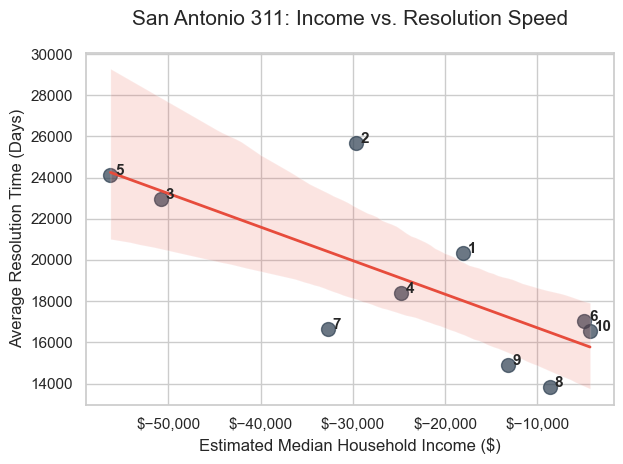

In [31]:
# 1. Set the visual style
sns.set_theme(style="whitegrid")

# 2. Create the plot
plt.clf() # Clear any existing plots
# We use regplot to automatically draw the line of best fit
plot = sns.regplot(
    data=district_stats,
    x='Median_Income',
    y='Avg_Res_Time',
    scatter_kws={'s': 100, 'alpha': 0.7, 'color': '#2c3e50'}, # Style the dots
    line_kws={'color': '#e74c3c', 'lw': 2}                  # Style the red trend line
)

# 3. Annotate the points with District numbers
# This helps you identify which specific district is an outlier
for i in range(district_stats.shape[0]):
    plt.text(
        x=district_stats.Median_Income[i] + 500, # Nudge text to the right
        y=district_stats.Avg_Res_Time[i],
        s=str(district_stats.District[i]),
        fontsize=11,
        fontweight='bold'
    )

# 4. Add Titles and Labels
plt.title('San Antonio 311: Income vs. Resolution Speed', fontsize=15, pad=20)
plt.xlabel('Estimated Median Household Income ($)', fontsize=12)
plt.ylabel('Average Resolution Time (Days)', fontsize=12)

# 5. Format the x-axis with dollar signs and commas
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# 6. Save the figure
plt.tight_layout()
plt.savefig('income_vs_resolution_scatter.png', dpi=300)

### 8b. Volume by District

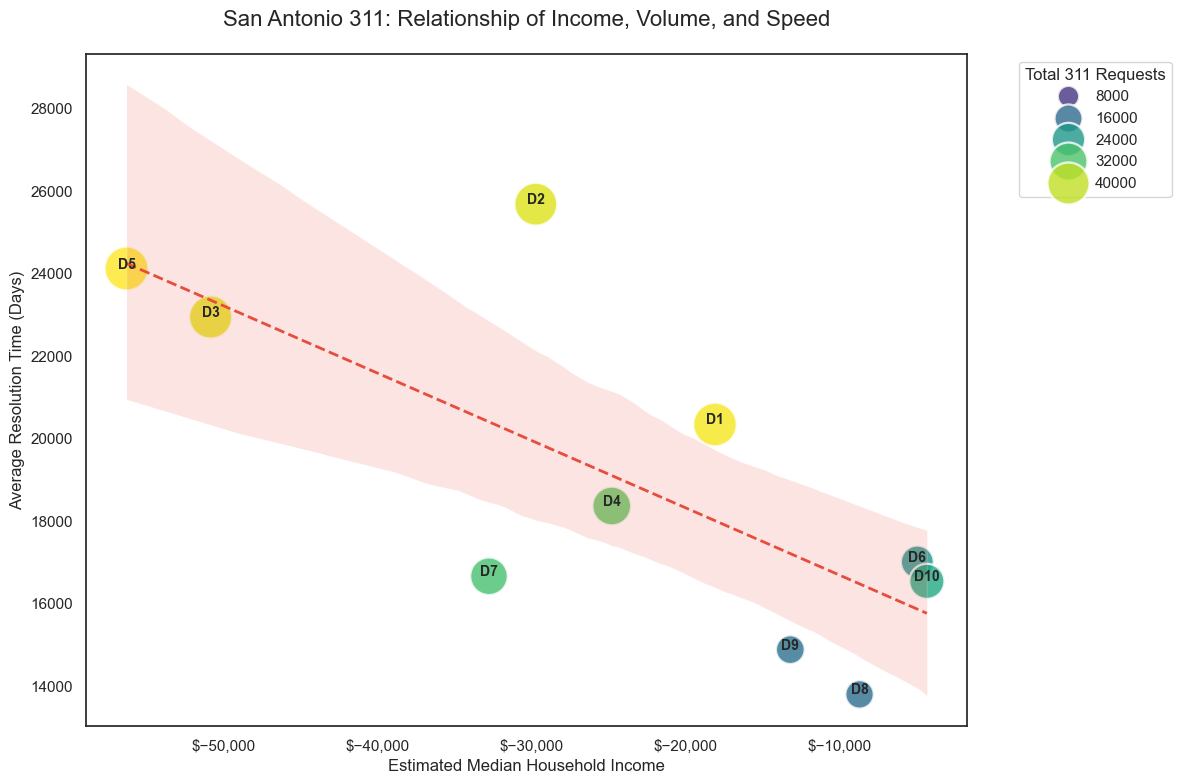

In [32]:
# 1. Set the visual style
sns.set_theme(style="white")
plt.figure(figsize=(12, 8))

# 2. Create the plot
# We use scatterplot instead of regplot to allow for 'hue' and 'size'
# Then we manually add the regression line
plot = sns.scatterplot(
    data=district_stats,
    x='Median_Income',
    y='Avg_Res_Time',
    size='Total_Volume',    # Larger dots = More 311 calls
    hue='Total_Volume',     # Darker colors = More 311 calls
    palette='viridis',      # Professional color scale
    sizes=(100, 1000),      # Range of dot sizes
    alpha=0.8,
    legend='brief'
)

# 3. Add the Regression Line (Trend Line)
sns.regplot(
    data=district_stats,
    x='Median_Income',
    y='Avg_Res_Time',
    scatter=False,          # Don't draw the dots again
    color='#e74c3c',
    line_kws={'ls': '--', 'lw': 2}
)

# 4. Annotate the District Numbers
for i in range(district_stats.shape[0]):
    plt.text(
        x=district_stats.Median_Income[i],
        y=district_stats.Avg_Res_Time[i] + 0.2, # Position text slightly above the dot
        s=f"D{int(district_stats.District[i])}",
        fontsize=10,
        fontweight='bold',
        ha='center'
    )

# 5. Formatting
plt.title('San Antonio 311: Relationship of Income, Volume, and Speed', fontsize=16, pad=20)
plt.xlabel('Estimated Median Household Income', fontsize=12)
plt.ylabel('Average Resolution Time (Days)', fontsize=12)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

# Move legend outside the plot area
plt.legend(title='Total 311 Requests', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('income_vs_resolution_volume_scatter.png', dpi=300)
plt.show()

### 8c. Income vs. Resolution Time — Choropleth

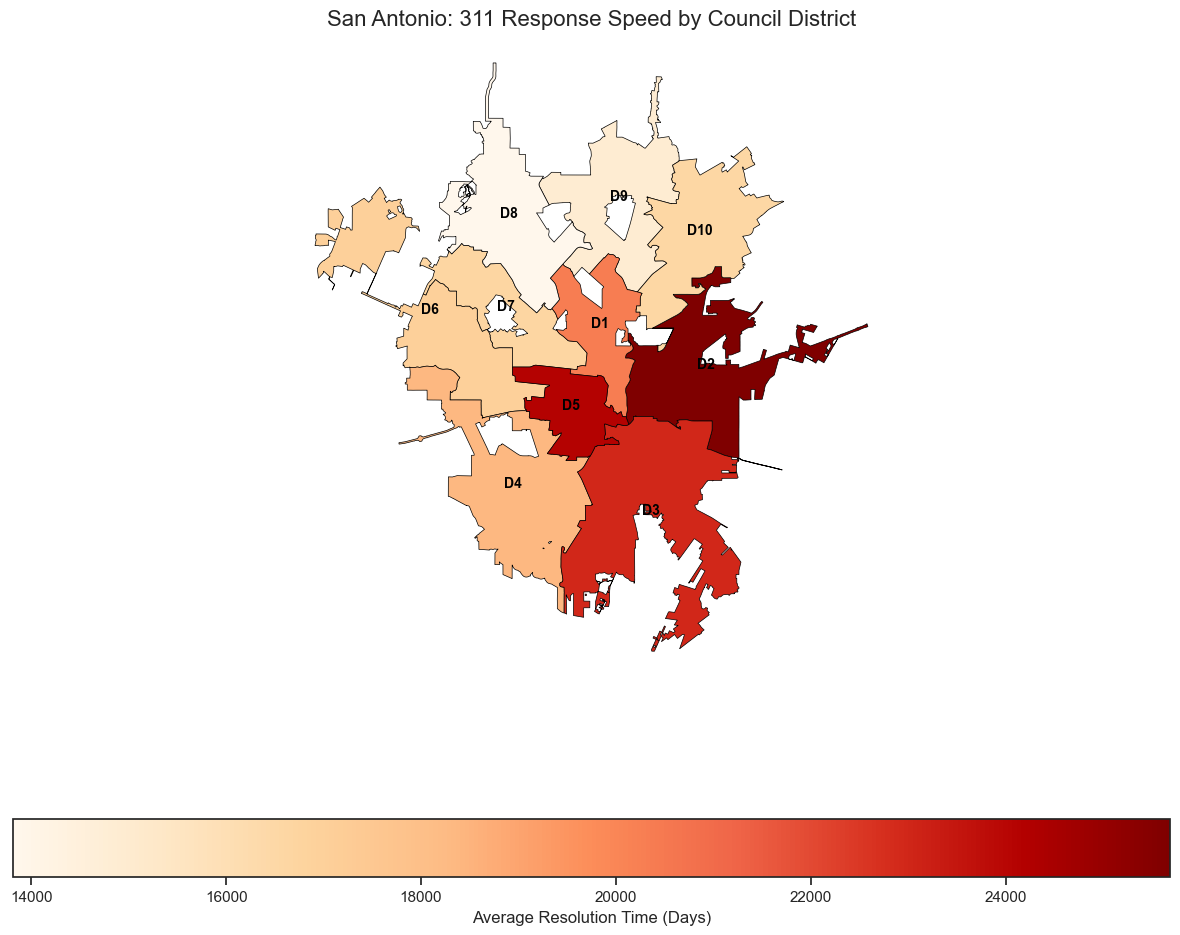

In [33]:
# 1. Merge your stats back into the Council District Shapefile
# We merge 'council_gdf' (the shapes) with 'district_stats' (the resolution numbers)
map_df = council.merge(district_stats, left_on='District', right_on='District')

# 2. Create the Map
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plotting the 'Avg_Res_Time' column
map_df.plot(
    column='Avg_Res_Time',
    cmap='OrRd',             # 'OrRd' = Orange to Red (Higher = Redder)
    legend=True,
    legend_kwds={'label': "Average Resolution Time (Days)", 'orientation': "horizontal"},
    edgecolor='black',       # Adds lines between districts
    linewidth=0.5,
    ax=ax
)

# 3. Add District Labels
# We calculate the center (centroid) of each district to place the label
for idx, row in map_df.iterrows():
    plt.annotate(
        text=f"D{int(row['District'])}",
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# 4. Final Formatting
plt.title('San Antonio: 311 Response Speed by Council District', fontsize=16)
ax.set_axis_off() # Hide the latitude/longitude coordinates for a cleaner look

plt.tight_layout()
plt.savefig('sa_311_heatmap.png', dpi=300)

### 8d. Map — Resolution Time Overlay

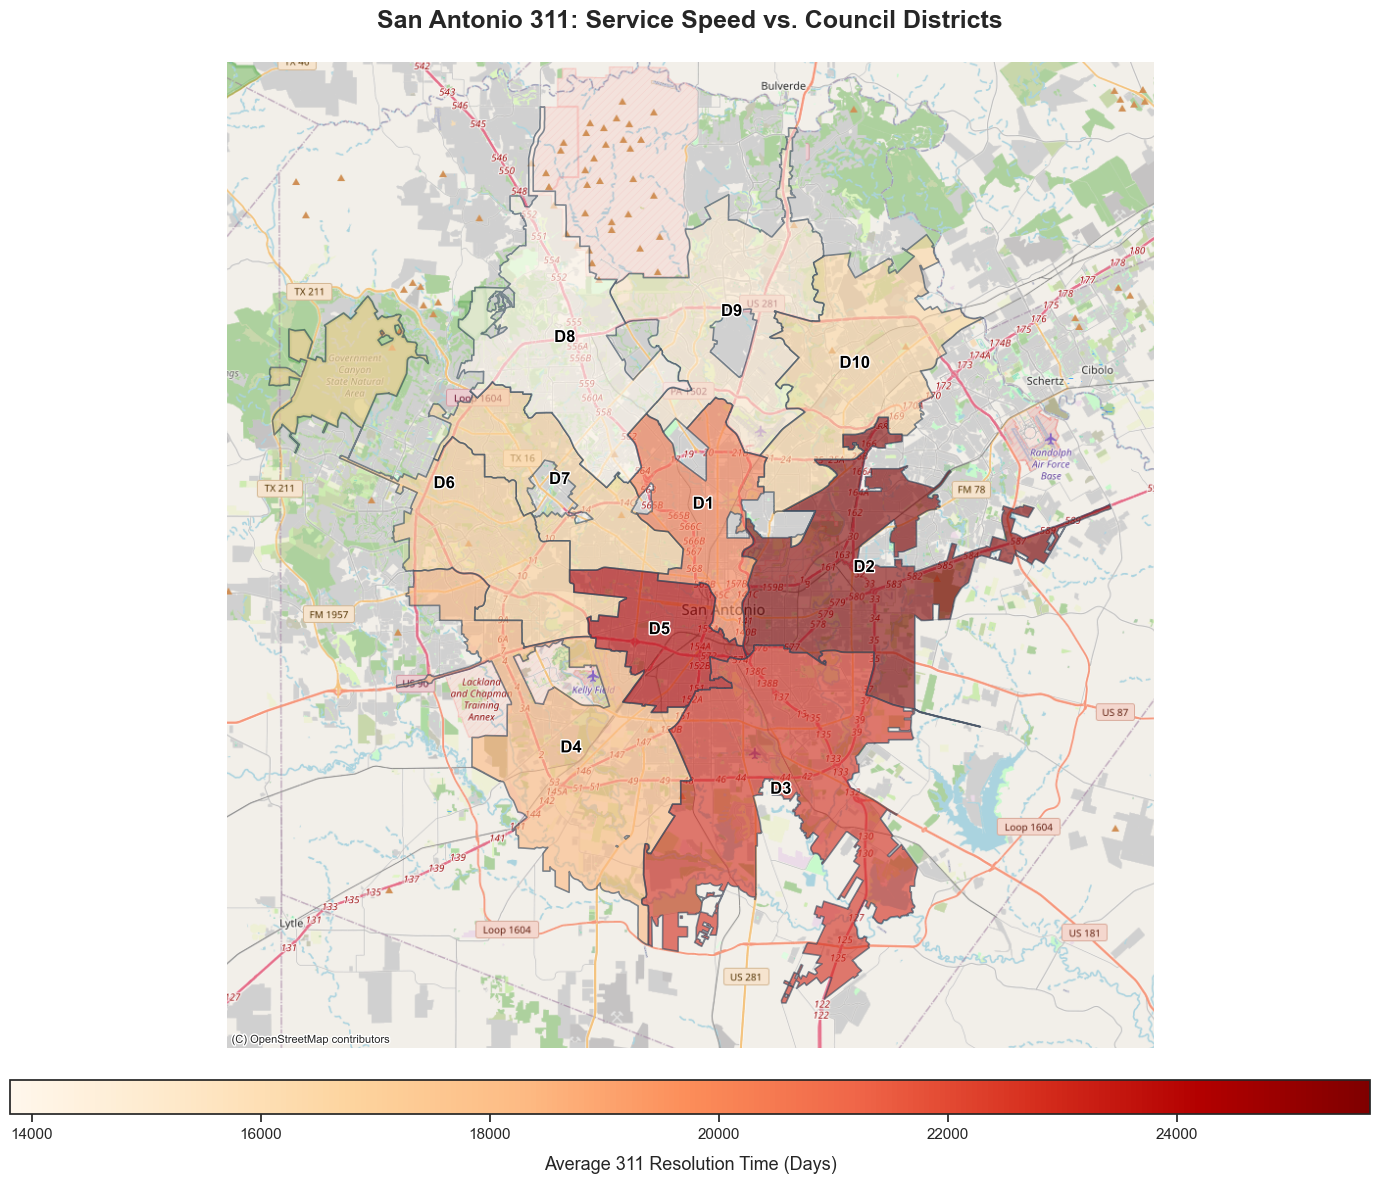

In [34]:
# 1. CRITICAL STEP: Convert to Web Mercator CRS
# contextily requires your data to be in the CRS of the basemap tiles (usually EPSG:3857)
map_df_mercator = map_df.to_crs(epsg=3857)

# 2. Setup the plot with a white background and good dimensions
fig, ax = plt.subplots(1, 1, figsize=(14, 12), facecolor='white')

# 3. Create the Choropleth (filled colors)
# We set a lower alpha so we can see the map through the colors
map_df_mercator.plot(
    column='Avg_Res_Time',
    cmap='OrRd',              # Orange to Red color scheme
    alpha=0.6,                # 60% opacity to show the basemap
    linewidth=1.2,
    edgecolor='#34495e',     # Dark, professional border color
    ax=ax,
    legend=False             # We will handle the legend separately for a cleaner look
)

# 4. Add District Labels
# These help users identify specific areas quickly
for idx, row in map_df_mercator.iterrows():
    ax.annotate(
        text=f"D{int(row['District'])}",
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        horizontalalignment='center',
        fontsize=12,
        fontweight='bold',
        color='black',
        path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=2, foreground="white")] # Add a white glow for readability
    )

# 5. Add the Basemap from Contextily
# We use the OpenStreetMap Mapnik style
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# 6. Add a Clean, Custom Colorbar/Legend
sm = plt.cm.ScalarMappable(cmap='OrRd', norm=plt.Normalize(vmin=map_df_mercator['Avg_Res_Time'].min(), vmax=map_df_mercator['Avg_Res_Time'].max()))
sm._A = [] # Required for ScalarMappable to work with matplotlib
cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.03, fraction=0.05, aspect=40)
cbar.set_label('Average 311 Resolution Time (Days)', fontsize=13, labelpad=10)

# 7. Final Polish: Title and Layout
plt.title('San Antonio 311: Service Speed vs. Council Districts', fontsize=18, fontweight='bold', pad=25)
ax.set_axis_off()          # Hide the lat/lon grid for a professional presentation
plt.tight_layout()

# 8. Display and Save
plt.savefig('sa_311_basemap.png', dpi=300, bbox_inches='tight')
plt.show()